# Propuesta 2
## Autor: Yasin Hanin Boukaddidi

In [ ]:
!pip install gensim
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.3 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
from gensim.models.fasttext import load_facebook_model
ft = load_facebook_model('/content/drive/MyDrive/PLN/wiki.simple.bin')

In [ ]:
# si lo desgargas desde el ordenador
# ft = load_facebook_model('wiki.simple.bin')

In [ ]:
import pandas as pd

df = pd.read_csv('tcga_simple_train.csv')
print(df.columns)

text_list = df['text'].to_list()
tags = list(sorted(set(df['t'].to_list())))
print(tags)

Index(['patient_id', 'text', 't'], dtype='object')
['T1', 'T2', 'T3', 'T4']


In [ ]:
%%capture
# Forzamos la instalación de una versión de NumPy compatible con spaCy 3.7 y scispacy
!pip install "numpy<2.0.0" spacy==3.7.4 scispacy==0.5.4
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz

import numpy as np
import spacy
import scispacy

# Cargamos el modelo científico
nlp = spacy.load("en_core_sci_sm")
print(f"NumPy version: {np.__version__}")
print("¡Modelo cargado correctamente!")

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def prepare_vocabulary(corpus):
    vocab = {}
    idx = 1
    # Usamos nlp.pipe para procesar en lotes (más rápido)
    for doc in nlp.pipe(corpus, batch_size=100, n_process=-1):
        tokens = [token.lemma_.lower() for token in doc
                  if not token.is_stop and not token.is_punct and token.text.isalnum()]
        for t in tokens:
            if t not in vocab:
                vocab[t] = idx
                idx += 1
    print(f'¡Vocabulario preparado! Tamaño: {len(vocab)}')
    return vocab

def prepare_sentences(corpus, word_index, maxlen):
    encoded_sentences = []
    # Usamos nlp.pipe también aquí para velocidad
    for doc in nlp.pipe(corpus, batch_size=100, n_process=-1):
        encoded_sentence = [word_index.get(token.text.lower(), 0) for token in doc]
        encoded_sentences.append(encoded_sentence)

    prepared = pad_sequences(encoded_sentences, maxlen=int(maxlen), padding='post', truncating='post')
    return prepared

/usr/local/lib/python3.12/dist-packages/spacy/util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.4). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


Longitud máxima: 3862
Longitud media: 547.0


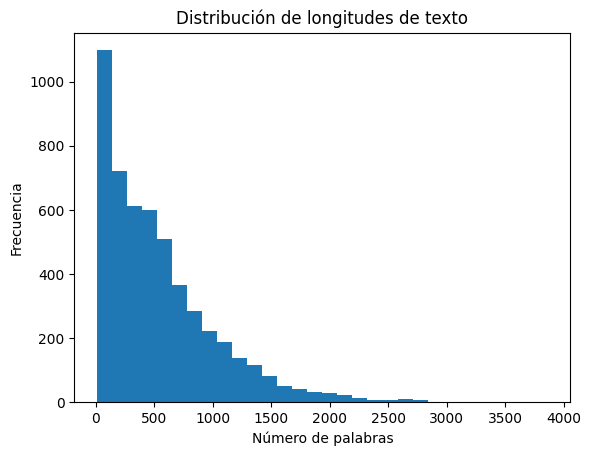

In [ ]:
import matplotlib.pyplot as plt

# Calculamos la longitud de cada texto (número de palabras)
sentence_lengths = [len(text.split()) for text in df['text']]

maxlen = np.mean(sentence_lengths)
maxlen = np.ceil(maxlen)

print(f'Longitud máxima: {max(sentence_lengths)}')
print(f'Longitud media: {maxlen}')

# Visualizamos la distribución
plt.hist(sentence_lengths, bins=30)
plt.title('Distribución de longitudes de texto')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
word_index = prepare_vocabulary(df['text'].to_list())

¡Vocabulario preparado! Tamaño: 26590


In [ ]:
prepared_sentences = prepare_sentences(df['text'].to_list(), word_index, maxlen)
print(f'Forma de la matriz: {prepared_sentences.shape}')
print("maxlen", maxlen)

Forma de la matriz: (5158, 547)
maxlen 547.0


In [ ]:
import numpy as np

vocab = list(word_index.keys())
vocab_size = len(vocab)
vector_size = ft.vector_size
matrix = []
for word in vocab:
    if word in ft.wv:
        matrix.append(ft.wv[word])
    else:
        matrix.append(np.zeros(vector_size))

print("Tam vocab:", vocab_size)
print("Tam vectores:", vector_size)
print(f"Matrix: {len(matrix)} x {len(matrix[0])}")

Tam vocab: 26590
Tam vectores: 300
Matrix: 26590 x 300


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score
import numpy as np

# Prepare labels
tags_dict = {tag: i for i, tag in enumerate(tags)}
y = df['t'].map(tags_dict).values

def get_average_vectors(sentences, word_index, embedding_matrix):
    embeddings = []
    for sentence in sentences:
        # Filtro 0 (padding/unknown)
        valid_indices = [idx for idx in sentence if idx > 0]
        if not valid_indices:
            embeddings.append(np.zeros(embedding_matrix.shape[1]))
            continue

        vecs = [embedding_matrix[idx-1] for idx in valid_indices]
        embeddings.append(np.mean(vecs, axis=0))
    return np.array(embeddings)

embedding_matrix_np = np.array(matrix)

X = get_average_vectors(prepared_sentences, word_index, embedding_matrix_np)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training shape: {X_train.shape}')
print(f'Testing shape: {X_test.shape}')

Training shape: (4126, 300)
Testing shape: (1032, 300)


In [ ]:
# Train SVM
svm_model = LinearSVC(random_state=42, C=1.0, max_iter=2000)
svm_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = svm_model.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f'Macro F1 Score: {macro_f1:.4f}\n')

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=tags))

Macro F1 Score: 0.5194

Classification Report:
              precision    recall  f1-score   support

          T1       0.57      0.55      0.56       260
          T2       0.51      0.57      0.54       351
          T3       0.58      0.63      0.60       317
          T4       0.61      0.27      0.37       104

    accuracy                           0.55      1032
   macro avg       0.57      0.50      0.52      1032
weighted avg       0.56      0.55      0.55      1032



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 1. Regresión Logística
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Comparación de Macro F1
f1_log = f1_score(y_test, y_pred_log, average='macro')
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

print(f'Macro F1 Logistic Regression: {f1_log:.4f}')
print(f'Macro F1 Random Forest: {f1_rf:.4f}')

print('\n--- Reporte Regresión Logística ---')
print(classification_report(y_test, y_pred_log, target_names=tags))

Macro F1 Logistic Regression: 0.4735
Macro F1 Random Forest: 0.4678

--- Reporte Regresión Logística ---
              precision    recall  f1-score   support

          T1       0.49      0.56      0.52       260
          T2       0.50      0.42      0.46       351
          T3       0.60      0.50      0.54       317
          T4       0.30      0.49      0.37       104

    accuracy                           0.49      1032
   macro avg       0.47      0.49      0.47      1032
weighted avg       0.51      0.49      0.49      1032



In [ ]:
print(classification_report(y_test, y_pred_rf, target_names=tags))

              precision    recall  f1-score   support

          T1       0.58      0.44      0.50       260
          T2       0.47      0.62      0.54       351
          T3       0.56      0.62      0.59       317
          T4       0.62      0.15      0.25       104

    accuracy                           0.53      1032
   macro avg       0.56      0.46      0.47      1032
weighted avg       0.54      0.53      0.51      1032



In [ ]:
from sklearn.naive_bayes import GaussianNB

# 3. Naive Bayes (Gaussian)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

f1_nb = f1_score(y_test, y_pred_nb, average='macro')

print(f'Macro F1 Naive Bayes: {f1_nb:.4f}')
print('\n--- Reporte Naive Bayes ---')
print(classification_report(y_test, y_pred_nb, target_names=tags))

Macro F1 Naive Bayes: 0.3735

--- Reporte Naive Bayes ---
              precision    recall  f1-score   support

          T1       0.41      0.54      0.47       260
          T2       0.42      0.26      0.32       351
          T3       0.45      0.44      0.45       317
          T4       0.21      0.33      0.26       104

    accuracy                           0.39      1032
   macro avg       0.37      0.39      0.37      1032
weighted avg       0.41      0.39      0.39      1032



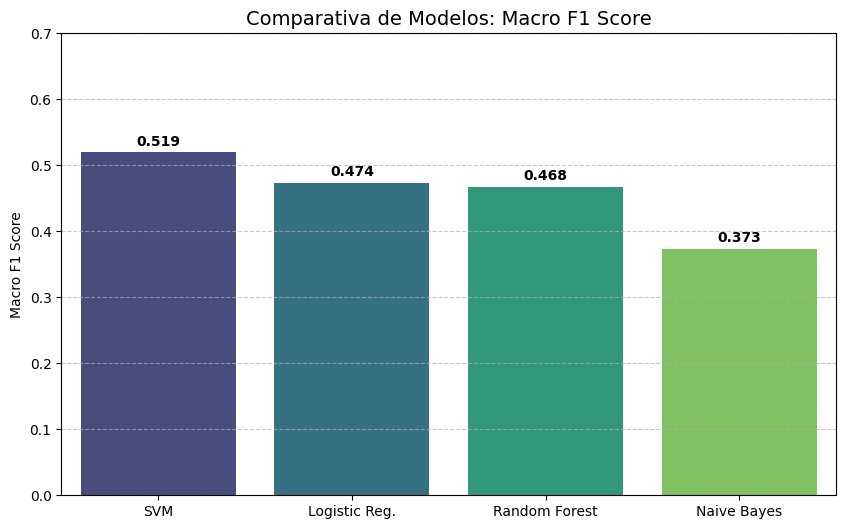

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

model_names = ['SVM', 'Logistic Reg.', 'Random Forest', 'Naive Bayes']
f1_scores = [0.5194, f1_log, f1_rf, f1_nb]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=f1_scores, hue=model_names, palette='viridis', legend=False)

for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.title('Comparativa de Modelos: Macro F1 Score', fontsize=14)
plt.ylabel('Macro F1 Score')
plt.ylim(0, 0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd

# Definimos los resultados obtenidos de las ejecuciones anteriores
results_data = {
    'Modelo': ['SVM (Linear)', 'Regresión Logística', 'Random Forest', 'Naive Bayes'],
    'Macro F1': [0.5194, f1_log, f1_rf, f1_nb],
    'Exactitud (Accuracy)': [0.55, 0.49, 0.53, 0.39],
    'Mejor Clase': ['T3 (0.60)', 'T3 (0.54)', 'T3 (0.59)', 'T1 (0.47)'],
    'Peor Clase': ['T4 (0.37)', 'T4 (0.37)', 'T4 (0.25)', 'T4 (0.26)']
}

# Crear el DataFrame
df_results = pd.DataFrame(results_data)

# Mostrar la tabla formateada
display(df_results.sort_values(by='Macro F1', ascending=False).style.background_gradient(subset=['Macro F1'], cmap='Blues'))

,Modelo,Macro F1,Exactitud (Accuracy),Mejor Clase,Peor Clase
0,SVM (Linear),0.519400,0.550000,T3 (0.60),T4 (0.37)
1,Regresión Logística,0.473549,0.490000,T3 (0.54),T4 (0.37)
2,Random Forest,0.467836,0.530000,T3 (0.59),T4 (0.25)
3,Naive Bayes,0.373466,0.390000,T1 (0.47),T4 (0.26)


In [ ]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# 1. Aplicar Oversampling
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print(f'Distribución original: {Counter(y_train)}')
print(f'Distribución balanceada: {Counter(y_train_res)}')

# 2. Re-entrenar modelos con datos balanceados
# SVM
svm_bal = LinearSVC(random_state=42, C=1.0, max_iter=3000)
svm_bal.fit(X_train_res, y_train_res)
y_pred_svm_bal = svm_bal.predict(X_test)

# Logistic Regression
log_bal = LogisticRegression(max_iter=1000, random_state=42)
log_bal.fit(X_train_res, y_train_res)
y_pred_log_bal = log_bal.predict(X_test)

# Random Forest
rf_bal = RandomForestClassifier(n_estimators=200, random_state=42)
rf_bal.fit(X_train_res, y_train_res)
y_pred_rf_bal = rf_bal.predict(X_test)

# 3. Calcular nuevos Macro F1
f1_svm_bal = f1_score(y_test, y_pred_svm_bal, average='macro')
f1_log_bal = f1_score(y_test, y_pred_log_bal, average='macro')
f1_rf_bal = f1_score(y_test, y_pred_rf_bal, average='macro')

print(f'\nNuevo Macro F1 SVM: {f1_svm_bal:.4f}')
print(f'Nuevo Macro F1 LogReg: {f1_log_bal:.4f}')
print(f'Nuevo Macro F1 Random Forest: {f1_rf_bal:.4f}')

Distribución original: Counter({1: 1401, 2: 1266, 0: 1042, 3: 417})
Distribución balanceada: Counter({0: 1401, 2: 1401, 1: 1401, 3: 1401})

Nuevo Macro F1 SVM: 0.4952
Nuevo Macro F1 LogReg: 0.4773
Nuevo Macro F1 Random Forest: 0.4860
